<a href="https://colab.research.google.com/github/Zanila-drip/Ossa/blob/master/AloeVera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importar librerias

In [11]:
import tensorflow as tf
import numpy as np
import cv2
import numpy as np
import matplotlib.pyplot as plt

Descomprimir zip

In [12]:
with zipfile.ZipFile("/content/aloVeraDataSet.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

* img size transforma las imagenes a un tama;o en especifico facilitando el proceso
* batch size se dedice cuantas imagenes se procesan


In [13]:
IMG_SIZE = 224
BATCH_SIZE = 16

trainData = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/crop_images",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)
valData = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/crop_images",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

Found 3495 files belonging to 3 classes.
Using 2796 files for training.
Found 3495 files belonging to 3 classes.
Using 699 files for validation.


Comprobar que cargo el datasetcorrectamente

In [14]:
print(trainData.class_names)

['healthy_leaf', 'rot', 'rust']


Usamos un modelo ya entrenado con imagenet

In [15]:
baseModelAloeVera = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
baseModelAloeVera.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Normalizacion de las imagenes y configuracion del entrenamiento

In [16]:
modelAloeVera = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./ 255),
    baseModelAloeVera,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation="softmax")
])
modelAloeVera.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Entrenamos el modelo

In [17]:
historyAloeVera = modelAloeVera.fit(
    trainData,
    validation_data=valData,
    epochs=10,
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 52s 187ms/step - accuracy: 0.7997 - loss: 0.4814 - val_accuracy: 0.8870 - val_loss: 0.3194
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9152 - loss: 0.2233 - val_accuracy: 0.9156 - val_loss: 0.2036
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.9464 - loss: 0.1466 - val_accuracy: 0.9428 - val_loss: 0.1460
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9703 - loss: 0.0915 - val_accuracy: 0.9485 - val_loss: 0.1379
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.9757 - loss: 0.0743 - val_accuracy: 0.9614 - val_loss: 0.1220
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9782 - loss: 0.0646 - val_accuracy: 0.9270 - val_loss: 0.1968
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9832 - loss: 0.0526 - val_accuracy: 0.9614 - val_loss: 0.0999
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9868 - loss: 0.0410 - val_a

Guardamos el modelo

In [18]:
modelAloeVera.save("aloeVeraModel.keras")

Probamos el modelo

In [19]:
model = tf.keras.models.load_model("/content/aloeVeraModel.keras")

#OpenCV

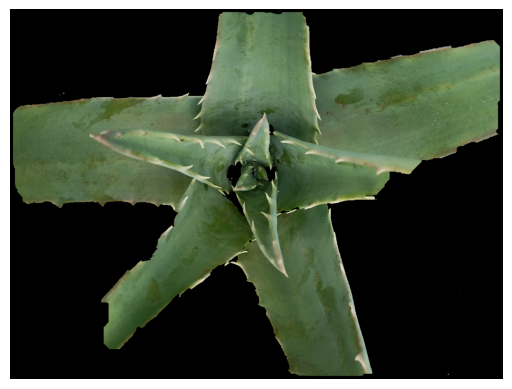

In [20]:
img = cv2.imread("test.jpeg")

mask = np.zeros(img.shape[:2], np.uint8)

bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)

rect = (10, 10, img.shape[1]-20, img.shape[0]-20)

cv2.grabCut(
    img,
    mask,
    rect,
    bgdModel,
    fgdModel,
    5,
    cv2.GC_INIT_WITH_RECT
)

mask2 = np.where(
    (mask == 2) | (mask == 0),
    0,
    1
).astype("uint8")

result = img * mask2[:, :, np.newaxis]

result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.imshow(result)
plt.axis("off")
plt.show()
result_resized = cv2.resize(result, (224, 224))
imagenArray = tf.keras.utils.img_to_array(result_resized)

In [21]:
imagenArray = tf.expand_dims(result_resized, 0)

In [22]:
predictions = model.predict(imagenArray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step


In [23]:
print(predictions)
informacion = trainData.class_names


[[2.3591453e-03 5.8560271e-04 9.9705529e-01]]


Predccion:  rust
Confianza: 57.5 %


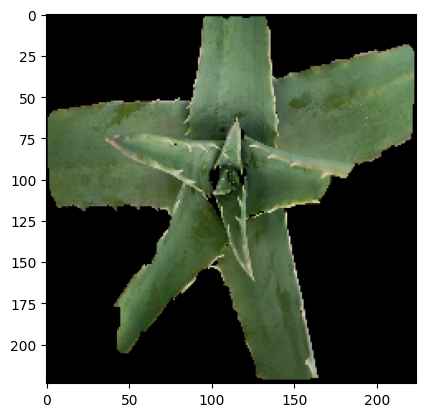

In [24]:
score = tf.nn.softmax(predictions[0])
plt.imshow(result_resized)
print("Predccion: ",
      informacion[np.argmax(score)])
print(
    "Confianza:",
    round(100 * np.max(score), 2),
    "%"
)